In [1]:
import	numpy	as	np
import	matplotlib.pyplot	as	plt
from	sklearn.datasets	import	load_iris
from	sklearn.tree	import	DecisionTreeClassifier,	plot_tree
from	scipy.stats	import	mode

In [2]:
#	Load	Iris	dataset
iris	=	load_iris()
X,	y	=	iris.data,	iris.target
n_samples	=	len(X)
#	Parameters
n_main_bags	=	5
samples_per_bag	=	30
subbags_per_bag	=	3
samples_per_subbag	=	30
np.random.seed(42)

In [5]:
#	Step	1:	Create	5	main	bags,	each	with	3	sub-bags	of	10	samples
subbags	=	[]
for	i	in	range(n_main_bags):
    main_indices	=	np.random.choice(n_samples,	samples_per_bag,	replace=True)
    X_main,	y_main	=	X[main_indices],	y[main_indices]
    for	j	in	range(subbags_per_bag):
        sub_indices	=	np.random.choice(samples_per_bag,	samples_per_subbag,	replace=True)
        X_sub,	y_sub	=	X_main[sub_indices],	y_main[sub_indices]
        subbags.append((X_sub,	y_sub))
print(f"Total	sub-bags	created:	{len(subbags)}")

Total	sub-bags	created:	15


In [6]:
#	Step	2:	Train	one	tree	per	sub-bag
trees	=	[]
for	idx,(X_sub,	y_sub)	in	enumerate(subbags):
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_sub,	y_sub)
    trees.append(tree)

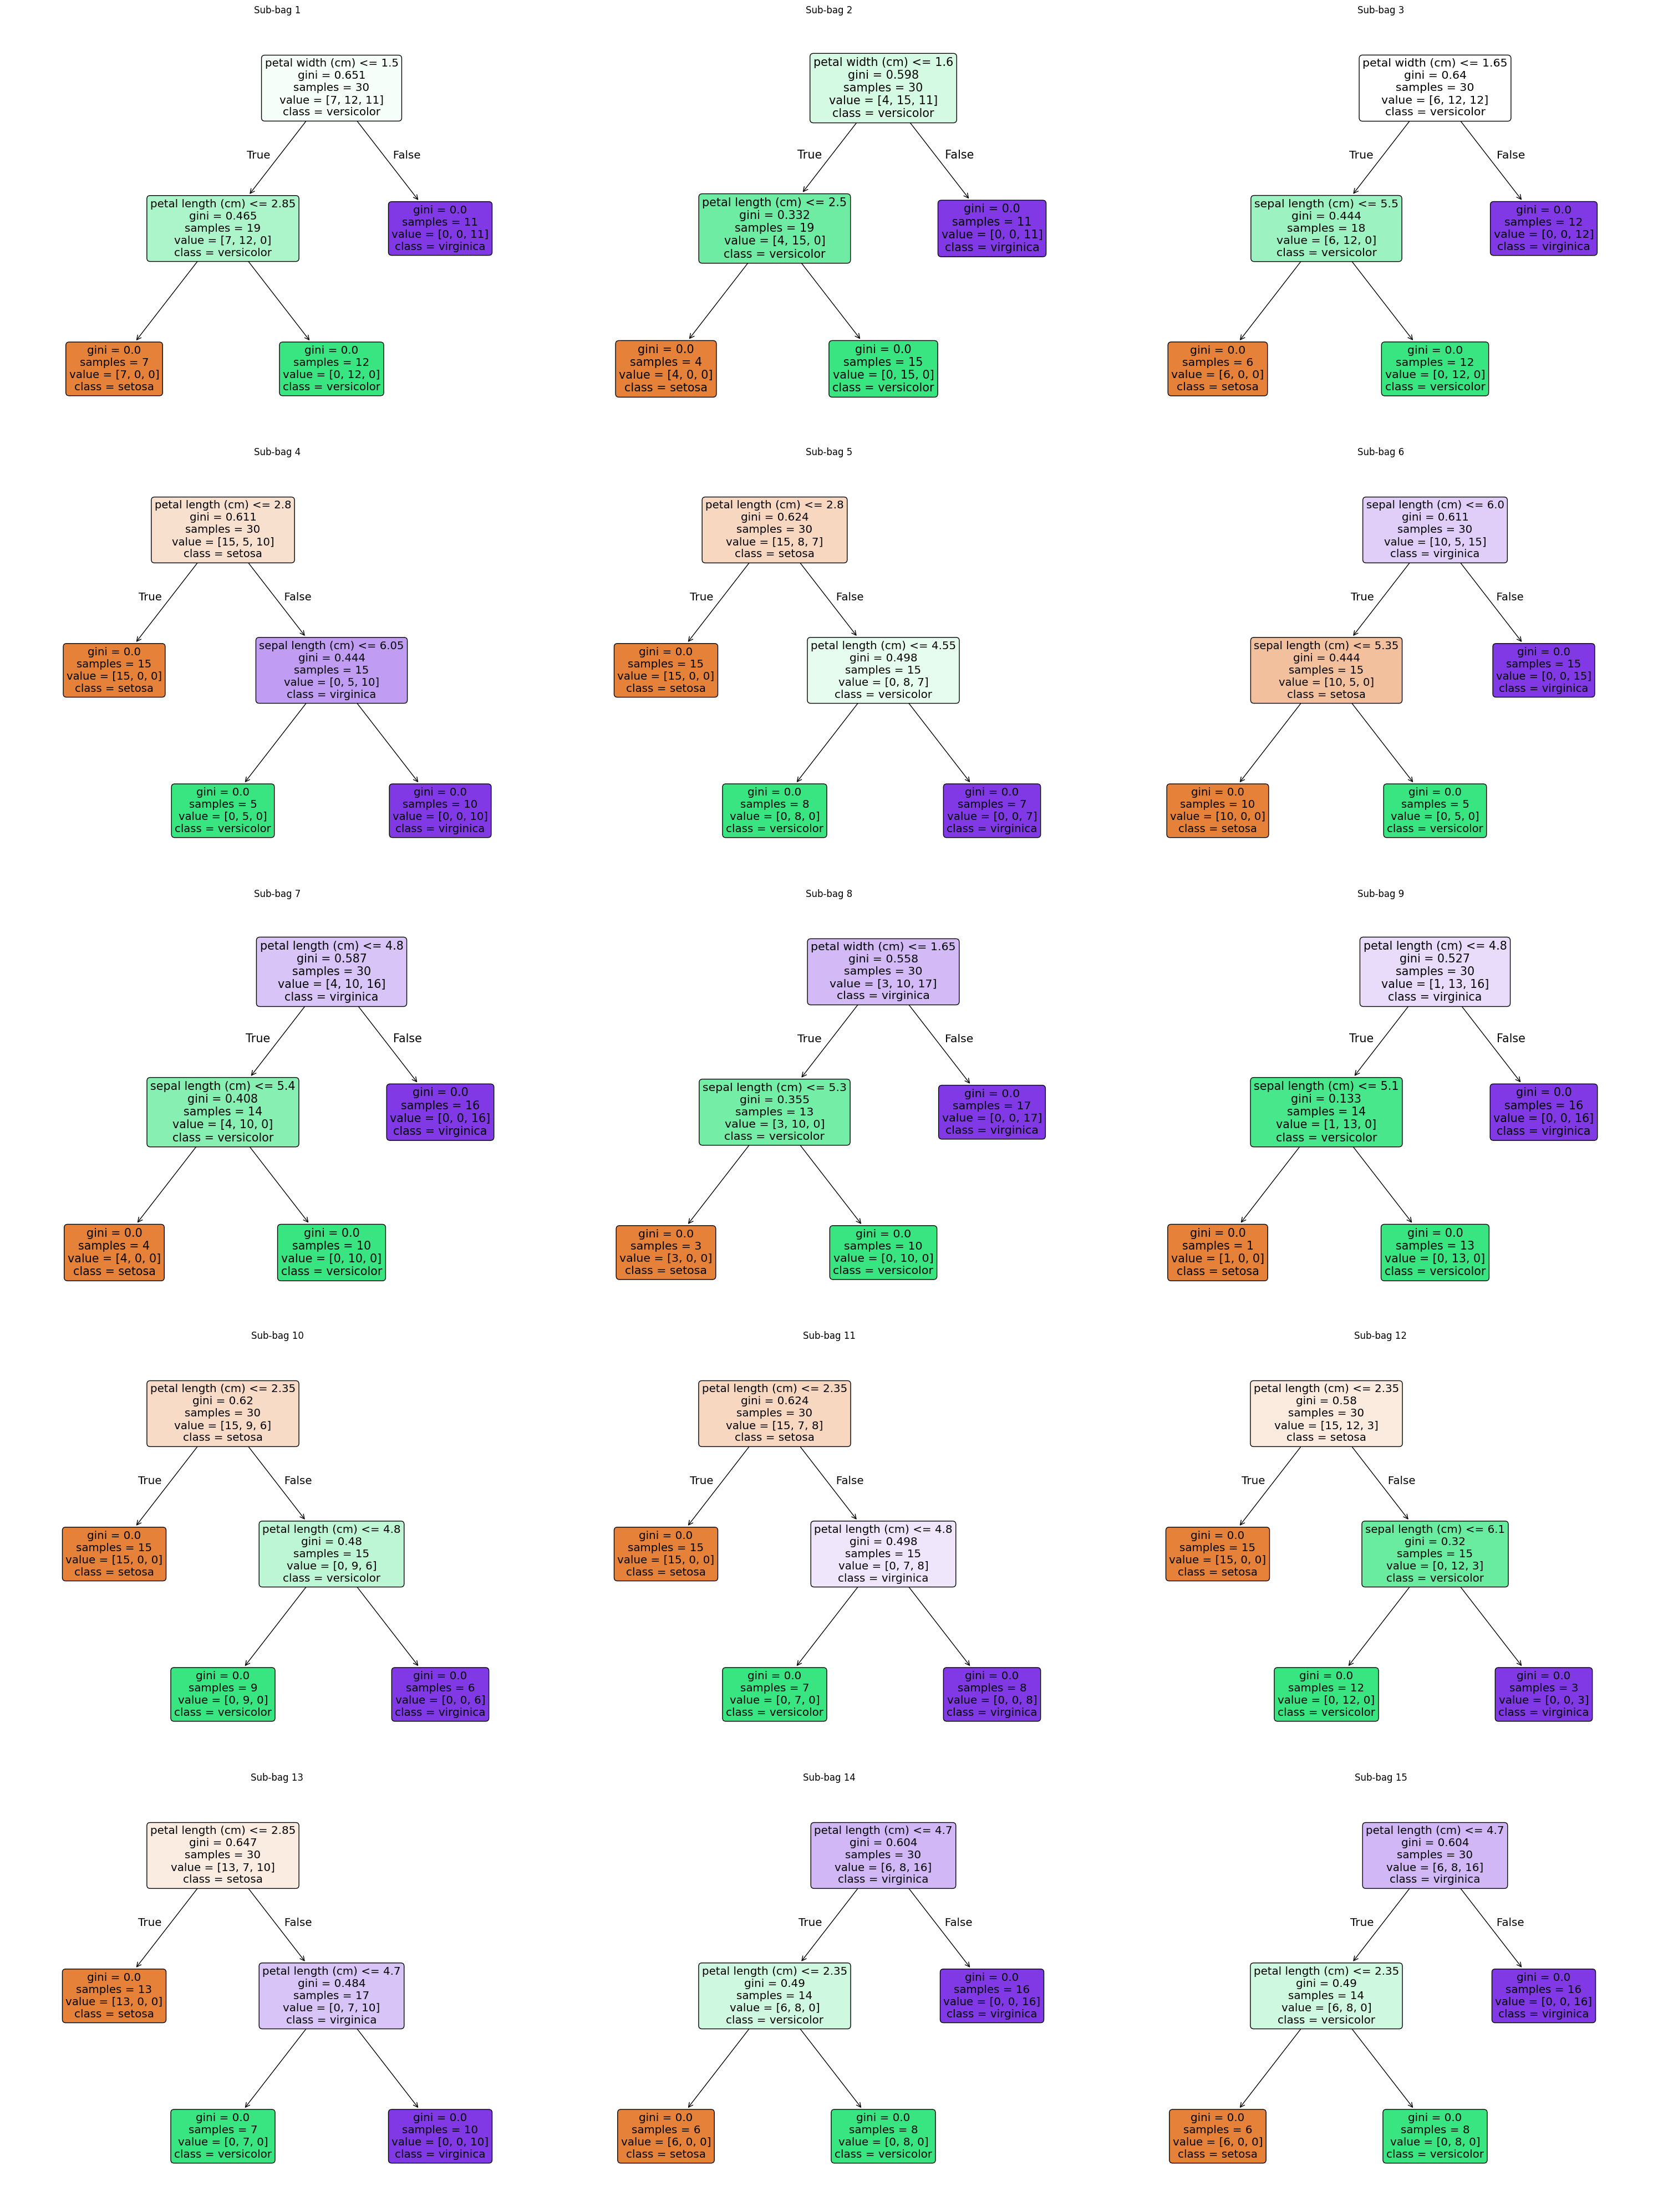

In [9]:
# Step 3: Plot all 15 trees in a grid (5 rows × 3 columns)
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(30, 40))  # adjust size for readability
axes = axes.flatten()

for idx, tree in enumerate(trees):
    plot_tree(
        tree,
        feature_names=iris.feature_names,
        class_names=iris.target_names,
        filled=True,
        rounded=True,
        ax=axes[idx]
    )
    axes[idx].set_title(f"Sub-bag {idx+1}")  # ✅ properly indented

plt.tight_layout()
plt.show()


In [10]:
# Step 4: Leave-one-sub-bag-out evaluation
accuracies = []

for test_idx in range(len(subbags)):
    train_trees = [trees[i] for i in range(len(subbags)) if i != test_idx]
    X_test, y_test = subbags[test_idx]
    predictions = []

    for tree in train_trees:
        predictions.append(tree.predict(X_test))

    predictions = np.array(predictions)
    final_preds, _ = mode(predictions, axis=0)
    acc = np.mean(final_preds.flatten() == y_test)
    accuracies.append(acc)

    print(f"Fold {test_idx+1}: Held-out Sub-bag Accuracy = {acc:.4f}")


Fold 1: Held-out Sub-bag Accuracy = 0.9667
Fold 2: Held-out Sub-bag Accuracy = 0.8333
Fold 3: Held-out Sub-bag Accuracy = 0.9667
Fold 4: Held-out Sub-bag Accuracy = 1.0000
Fold 5: Held-out Sub-bag Accuracy = 1.0000
Fold 6: Held-out Sub-bag Accuracy = 1.0000
Fold 7: Held-out Sub-bag Accuracy = 1.0000
Fold 8: Held-out Sub-bag Accuracy = 0.9667
Fold 9: Held-out Sub-bag Accuracy = 1.0000
Fold 10: Held-out Sub-bag Accuracy = 1.0000
Fold 11: Held-out Sub-bag Accuracy = 1.0000
Fold 12: Held-out Sub-bag Accuracy = 1.0000
Fold 13: Held-out Sub-bag Accuracy = 0.9667
Fold 14: Held-out Sub-bag Accuracy = 0.9667
Fold 15: Held-out Sub-bag Accuracy = 1.0000


In [12]:
#	Step	5:	Report	best	performing	sub-bag
best_idx = np.argmax(accuracies)
print("\nSummary:")
print("Average	accuracy across	15	folds:",np.mean(accuracies))
print(f"Highest	accuracy achieved by Sub-bag {best_idx+1} → Accuracy = {accuracies[best_idx]:.4f}")


Summary:
Average	accuracy across	15	folds: 0.9777777777777779
Highest	accuracy achieved by Sub-bag 4 → Accuracy = 1.0000
